
[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Index(['Price', 'CVol', 'Change', '% Change', '% Return',
       'Total Return (Gross)', 'Cumulative Return %', 'Open', 'High', 'Low',
       'Cumulative Change %'],
      dtype='str')


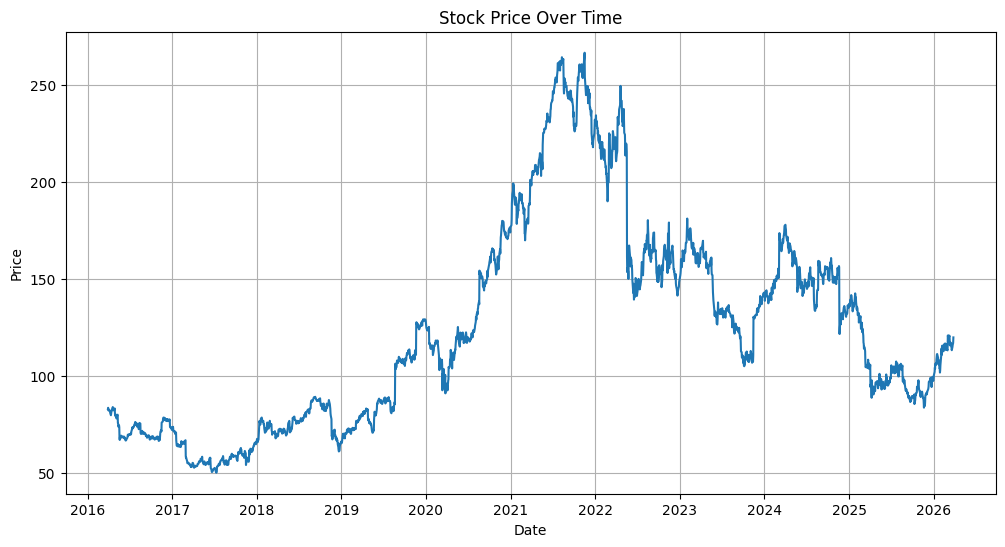

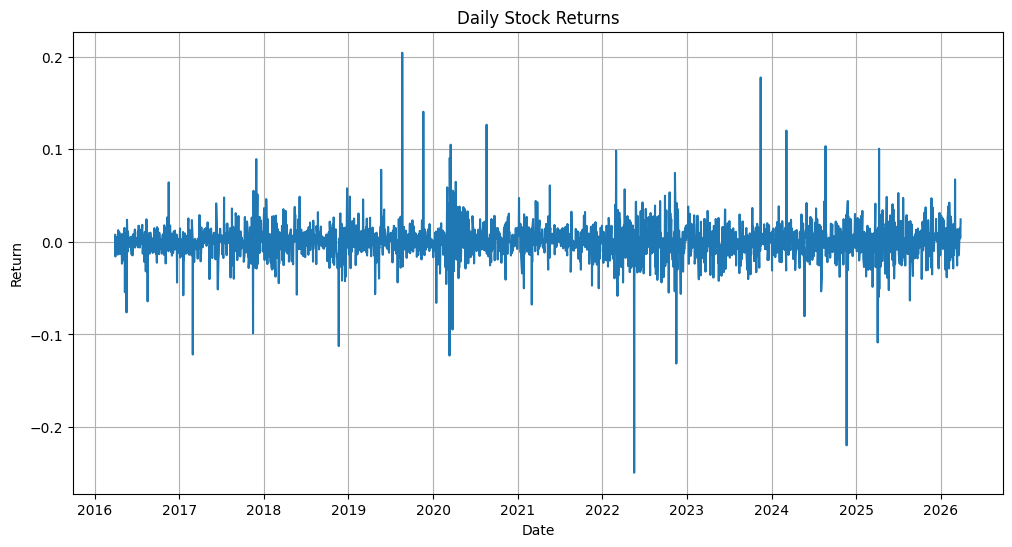

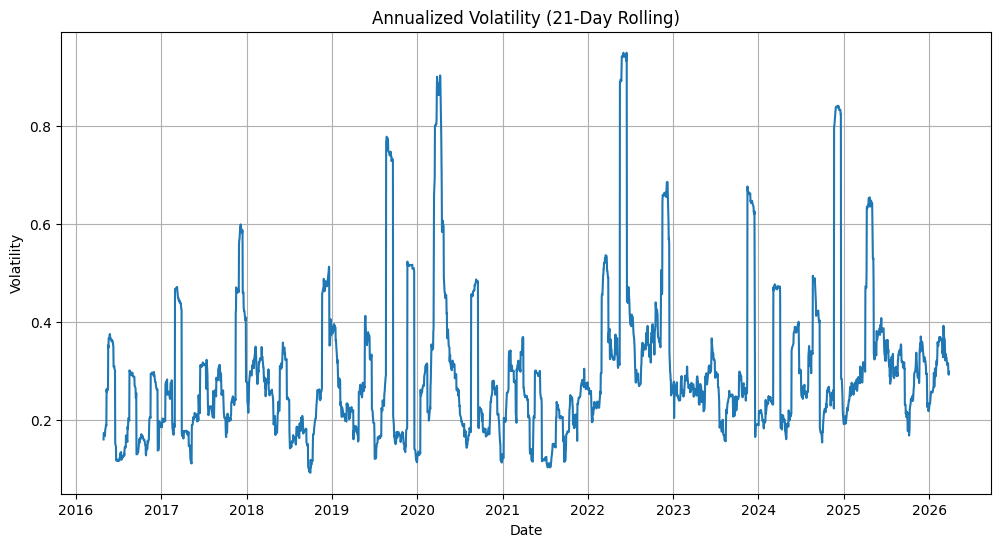

In [7]:
# # You can write your codes in this file and Commit&push changes to submit OR upload your ipynb file in the repository.
!pip install pandas numpy matplotlib 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. LOAD THE CSV
# ===============================
df = pd.read_csv("PriceHistory.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")

# Sort from oldest to newest
df = df.sort_values("Date")

# Set Date as index
df.set_index("Date", inplace=True)

# Check columns
print(df.columns)

# Your file uses "Price"
price_col = "Price"

# ===============================
# 2. PLOT STOCK PRICES
# ===============================
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[price_col])
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# ===============================
# 3. CALCULATE DAILY RETURNS
# ===============================
df["Returns"] = df[price_col].pct_change()

# Remove missing first row
df = df.dropna()

# ===============================
# 4. PLOT DAILY RETURNS
# ===============================
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Returns"])
plt.title("Daily Stock Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

# ===============================
# 5. CALCULATE ANNUALIZED VOLATILITY
# ===============================
# 21 trading days ~= 1 month rolling window
df["Rolling Volatility"] = df["Returns"].rolling(window=21).std()

# Annualized volatility
df["Annualized Volatility"] = df["Rolling Volatility"] * np.sqrt(252)

# ===============================
# 6. PLOT ANNUALIZED VOLATILITY
# ===============================
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Annualized Volatility"])
plt.title("Annualized Volatility (21-Day Rolling)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()